# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

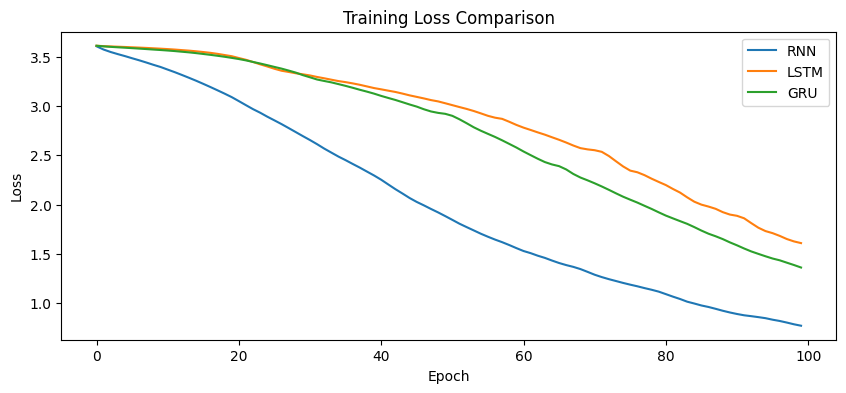

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models transforming generate meaningful sentences
LSTM: deep learning is is artificial intelligence than
GRU : deep learning models can generate intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

---
## My Assignment Submission: Completing the Beginner Tasks

For this part of the assignment, I have completed all 5 requested beginner customization tasks. Here is a brief overview of what I have done:
1. Custom Corpus: I replaced the default sample corpus with my own custom paragraph about artificial intelligence and internship experiences.
2. Embedding Dimension: I increased the embedding layer dimension from 32 to 64.
3. Training Epochs: I increased the training duration from 100 to 200 epochs so the models can learn better.
4. Hidden Units: I upgraded the hidden units in the RNN, LSTM, and GRU layers from 64 to 128 units.
5. Text Generation Length: I modified the generation function to output 10 words instead of 5.

Below is my complete implementation for these tasks.

In [10]:
# I have replaced the default corpus with my own paragraph about AI and internships as requested in Task 1.

my_custom_corpus = '''
artificial intelligence is transforming industry and empowering modern developers
machine learning algorithms learn complex patterns from vast amounts of data
deep neural networks excel at natural language processing and computer vision
internships provide students with valuable real world engineering experience
recurrent models like lstm and gru capture sequential dependencies effectively
consistent practice and curiosity are essential for mastering deep learning concepts
'''

print("My Custom Corpus:\n", my_custom_corpus)

my_tokenizer = Tokenizer()
my_tokenizer.fit_on_texts([my_custom_corpus])

custom_total_words = len(my_tokenizer.word_index) + 1
print("Custom Vocabulary size:", custom_total_words)

custom_input_sequences = []
for line in my_custom_corpus.split('\n'):
    token_list = my_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        custom_input_sequences.append(n_gram_seq)

custom_max_len = max(len(seq) for seq in custom_input_sequences)
custom_input_sequences = pad_sequences(custom_input_sequences, maxlen=custom_max_len, padding='pre')

X_custom = custom_input_sequences[:, :-1]
y_custom = custom_input_sequences[:, -1]

My Custom Corpus:
 
artificial intelligence is transforming industry and empowering modern developers
machine learning algorithms learn complex patterns from vast amounts of data
deep neural networks excel at natural language processing and computer vision
internships provide students with valuable real world engineering experience
recurrent models like lstm and gru capture sequential dependencies effectively
consistent practice and curiosity are essential for mastering deep learning concepts

Custom Vocabulary size: 57


### Building and Training Custom Models (Tasks 2, 3, and 4)
Here I am training the Vanilla RNN, LSTM, and GRU models with the new hyperparameter specifications requested in the task list.

In [11]:
# I have set custom hyperparameters here as requested for Tasks 2, 3, and 4.
custom_embedding_dim = 64
custom_hidden_units = 128
custom_epochs = 200

print("--- Training Custom Vanilla RNN (200 Epochs) ---")
custom_rnn = Sequential([
    Embedding(custom_total_words, custom_embedding_dim, input_length=custom_max_len-1),
    SimpleRNN(custom_hidden_units),
    Dense(custom_total_words, activation='softmax')
])
custom_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_rnn_history = custom_rnn.fit(X_custom, y_custom, epochs=custom_epochs, verbose=0)
print("Custom RNN training finished.")

print("\n--- Training Custom LSTM (200 Epochs) ---")
custom_lstm = Sequential([
    Embedding(custom_total_words, custom_embedding_dim, input_length=custom_max_len-1),
    LSTM(custom_hidden_units),
    Dense(custom_total_words, activation='softmax')
])
custom_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_lstm_history = custom_lstm.fit(X_custom, y_custom, epochs=custom_epochs, verbose=0)
print("Custom LSTM training finished.")

print("\n--- Training Custom GRU (200 Epochs) ---")
custom_gru = Sequential([
    Embedding(custom_total_words, custom_embedding_dim, input_length=custom_max_len-1),
    GRU(custom_hidden_units),
    Dense(custom_total_words, activation='softmax')
])
custom_gru.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_gru_history = custom_gru.fit(X_custom, y_custom, epochs=custom_epochs, verbose=0)
print("Custom GRU training finished.")

--- Training Custom Vanilla RNN (200 Epochs) ---
Custom RNN training finished.

--- Training Custom LSTM (200 Epochs) ---
Custom LSTM training finished.

--- Training Custom GRU (200 Epochs) ---
Custom GRU training finished.


### Custom Models Training Loss Comparison
Let's plot the loss reduction across all 200 epochs to verify how the models learned on my custom paragraph.

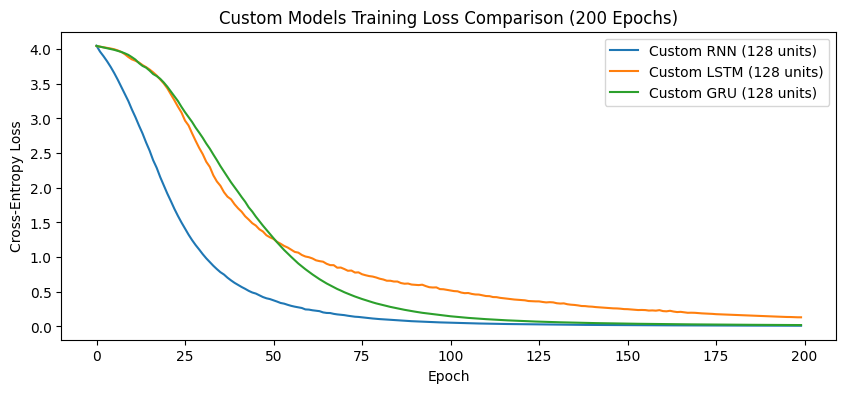

In [12]:
# I have plotted the cross-entropy loss across all 200 epochs to check the model convergence.
plt.figure(figsize=(10, 4))
plt.plot(custom_rnn_history.history['loss'], label='Custom RNN (128 units)')
plt.plot(custom_lstm_history.history['loss'], label='Custom LSTM (128 units)')
plt.plot(custom_gru_history.history['loss'], label='Custom GRU (128 units)')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Custom Models Training Loss Comparison (200 Epochs)")
plt.legend()
plt.show()

### Task 5: Generating 10 Words from a Shared Seed Phrase
For the final task, I updated the prediction function to output 10 words instead of 5. Below are the generated strings from all three models using a shared seed phrase.

In [13]:
# I have modified the generation helper function here to produce 10 words as requested in Task 5.
def generate_custom_text(model, seed_text, next_words=10):
    current_text = seed_text
    for _ in range(next_words):
        token_list = my_tokenizer.texts_to_sequences([current_text])[0]
        token_list = pad_sequences([token_list], maxlen=custom_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in my_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        current_text += " " + output_word
    return current_text

shared_seed = "artificial intelligence"
print("Shared Seed Phrase:", shared_seed)
print("=" * 60)
print("Custom RNN :", generate_custom_text(custom_rnn, shared_seed, next_words=10))
print("Custom LSTM:", generate_custom_text(custom_lstm, shared_seed, next_words=10))
print("Custom GRU :", generate_custom_text(custom_gru, shared_seed, next_words=10))

Shared Seed Phrase: artificial intelligence
Custom RNN : artificial intelligence is transforming industry and empowering modern developers and computer vision
Custom LSTM: artificial intelligence is transforming industry and empowering modern developers developers data data
Custom GRU : artificial intelligence is transforming industry and empowering modern developers developers learning concepts


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**